<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 91.6 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-01-12 06:30:22--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  55.5MB/s    in 2.7s    

2026-01-12 06:30:26 (55.5 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


/tmp/ipykernel_300/1566692044.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['SOPartFreq_Numeric'] = df['SOPartFreq'].replace(part_freq_map)


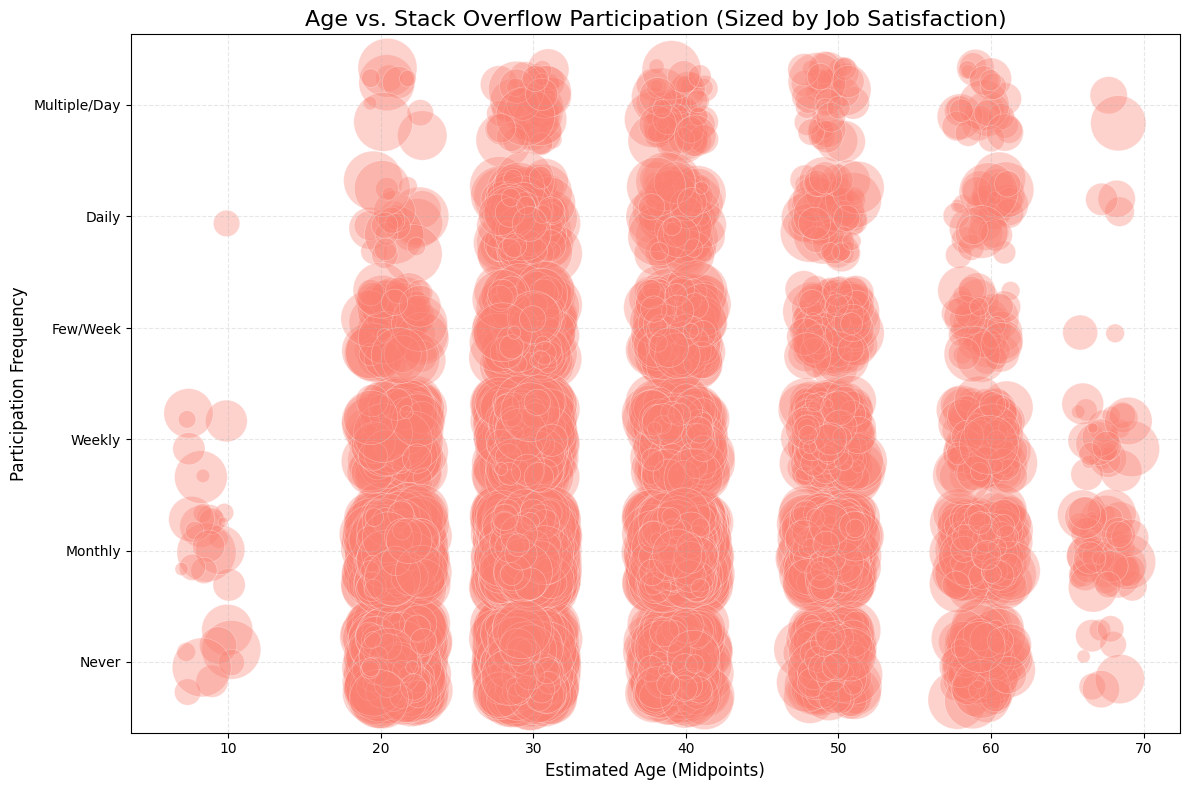

Bubble plot updated with complete frequency mapping. Larger bubbles indicate higher Job Satisfaction.


In [5]:
##Write your code here
import numpy as np


# 1. Prepare Age Midpoints (Numeric)
# This converts the categorical age ranges into a continuous numerical scale
age_midpoint_map = {
    'Under 18 years old': 8.5, 
    '18-24 years old': 21.0, 
    '25-34 years old': 29.5,
    '35-44 years old': 39.5, 
    '45-54 years old': 49.5, 
    '55-64 years old': 59.5,
    '65 years or older': 67.5
}
df['Age_Midpoint'] = df['Age'].replace(age_midpoint_map)

# 2. Map Participation Frequency (SOPartFreq) to Numeric Scale
# We assign an ordinal scale (0-5) to represent increasing levels of engagement
part_freq_map = {
    'I have never participated in Q&A on Stack Overflow': 0,
    'Less than once per month or monthly': 1,
    'A few times per month or weekly': 2,
    'A few times per week': 3,
    'Daily or almost daily': 4,
    'Multiple times per day': 5
}
df['SOPartFreq_Numeric'] = df['SOPartFreq'].replace(part_freq_map)

# 3. Ensure columns are numeric and drop NaNs
# We use JobSatPoints_6 for the bubble size (ensure this column is present and numeric)
df['Age_Midpoint'] = pd.to_numeric(df['Age_Midpoint'], errors='coerce')
df['SOPartFreq_Numeric'] = pd.to_numeric(df['SOPartFreq_Numeric'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop rows with missing values in any of the three analysis dimensions
plot_data = df.dropna(subset=['Age_Midpoint', 'SOPartFreq_Numeric', 'JobSatPoints_6']).copy()

# 4. Add "Jitter" to handle overlapping discrete points
# Since Age and Frequency are categorical, many users land on the exact same coordinate.
# Jittering spreads the points slightly so density is visible.
plot_data['Age_Jitter'] = plot_data['Age_Midpoint'] + np.random.uniform(-1.8, 1.8, len(plot_data))
plot_data['Freq_Jitter'] = plot_data['SOPartFreq_Numeric'] + np.random.uniform(-0.35, 0.35, len(plot_data))

# 5. Create the Bubble Plot
plt.figure(figsize=(12, 8))

# Size (s) is controlled by Job Satisfaction score
scatter = plt.scatter(
    x=plot_data['Age_Jitter'], 
    y=plot_data['Freq_Jitter'],
    s=plot_data['JobSatPoints_6'] * 18,  # Scaling factor for visibility
    alpha=0.35,                         # High transparency to handle overplotting
    color='salmon',
    edgecolors='w',
    linewidth=0.5
)

# 6. Formatting Axes and Labels
plt.title('Age vs. Stack Overflow Participation (Sized by Job Satisfaction)', fontsize=16)
plt.xlabel('Estimated Age (Midpoints)', fontsize=12)
plt.ylabel('Participation Frequency', fontsize=12)

# Set Y-axis ticks to show the original categories for intuitive reading
plt.yticks(
    ticks=list(part_freq_map.values()), 
    labels=['Never', 'Monthly', 'Weekly', 'Few/Week', 'Daily', 'Multiple/Day']
)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Bubble plot updated with complete frequency mapping. Larger bubbles indicate higher Job Satisfaction.")

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


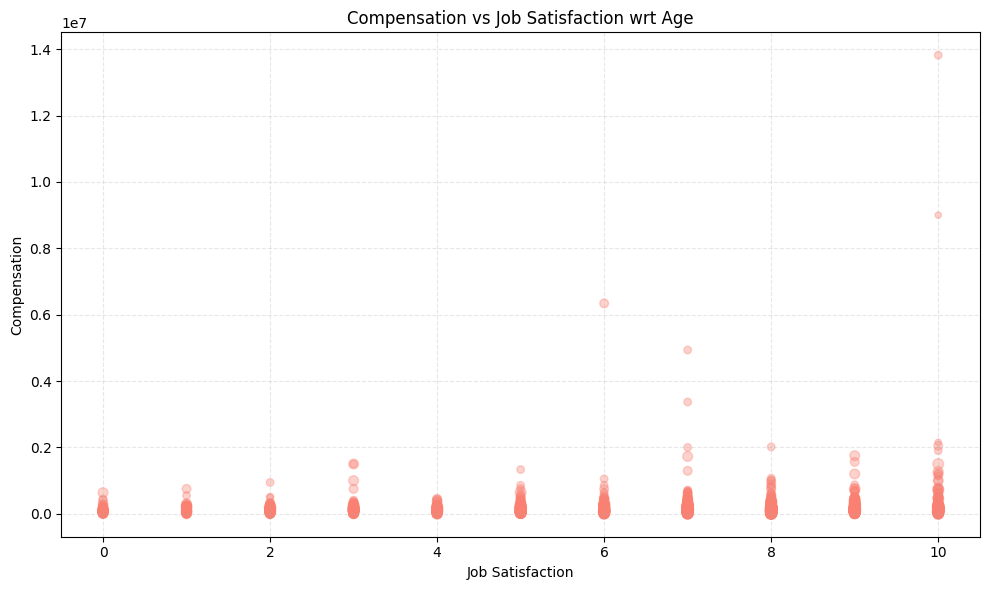

In [23]:
##Write your code here

plt.figure(figsize = (10,6))

plt.scatter(
    x = df['JobSat'],
    y = df['ConvertedCompYearly'],
    s = df['Age_Midpoint'],
    color = 'salmon',
    alpha = 0.35,
    #edgecolors = 'w',
    #linewidth=0.5
);

plt.title('Compensation vs Job Satisfaction wrt Age')
plt.xlabel('Job Satisfaction')
plt.ylabel('Compensation')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



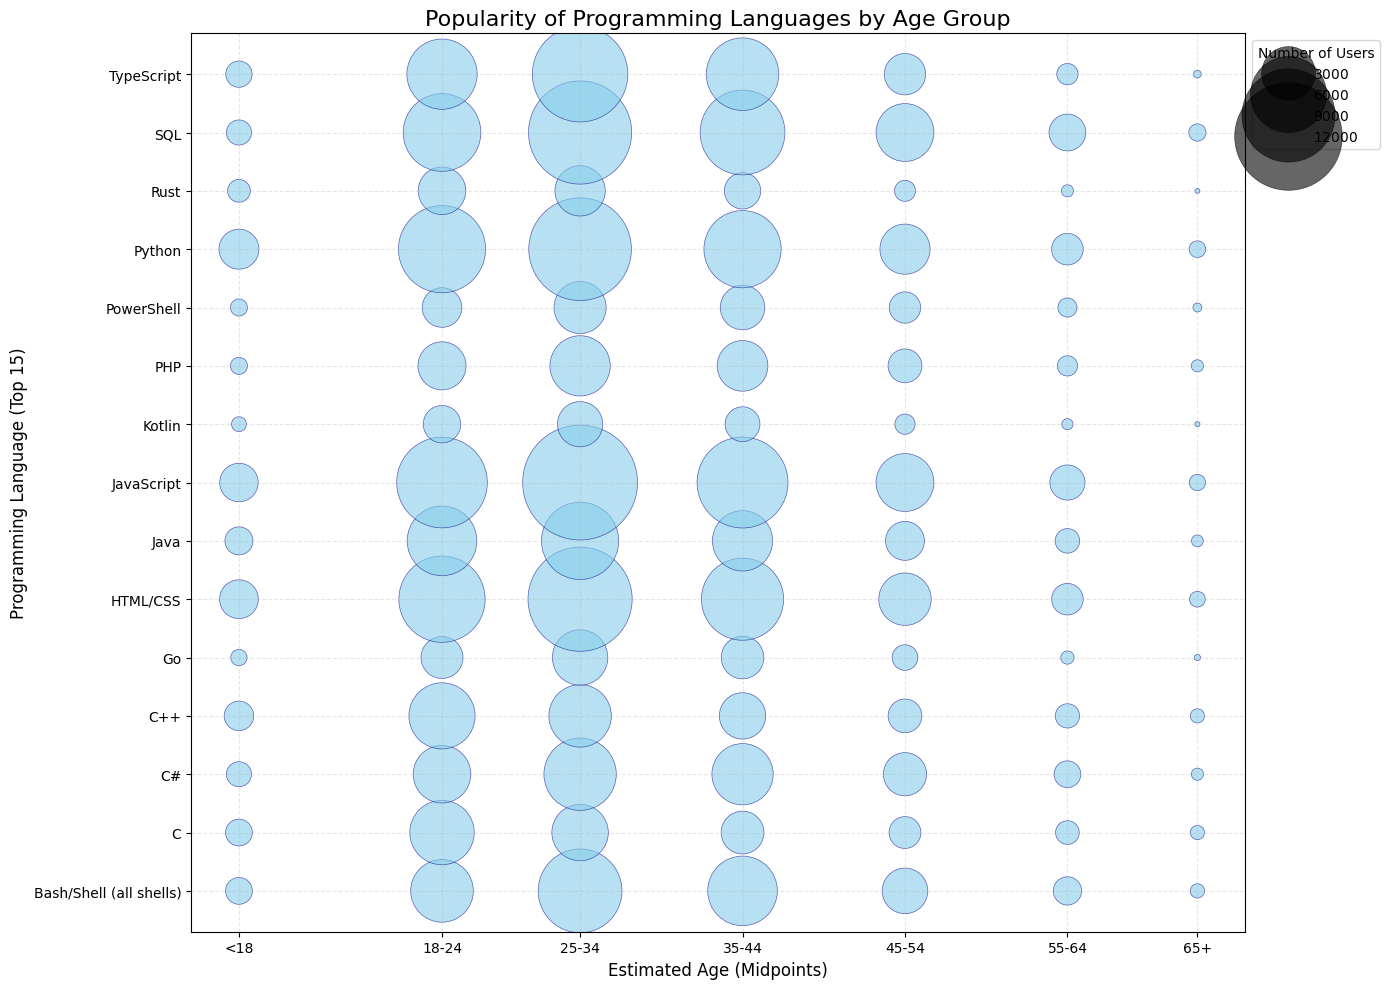

Bubble plot generated for top 15 languages. X-axis shows Age groups, Y-axis shows technology, and bubble size represents frequency.


In [26]:
##Write your code here

# 1. Prepare Age Midpoints (Numeric)
age_midpoint_map = {
    'Under 18 years old': 8.5, 
    '18-24 years old': 21.0, 
    '25-34 years old': 29.5,
    '35-44 years old': 39.5, 
    '45-54 years old': 49.5, 
    '55-64 years old': 59.5,
    '65 years or older': 67.5
}
df['Age_Midpoint'] = df['Age'].replace(age_midpoint_map)
df['Age_Midpoint'] = pd.to_numeric(df['Age_Midpoint'], errors='coerce')

# 2. Process Multi-select Languages
# We drop rows with missing values in either required column
df_clean = df.dropna(subset=['LanguageHaveWorkedWith', 'Age_Midpoint']).copy()

# Split the semicolon-separated strings and explode into individual rows
df_clean['Language'] = df_clean['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_clean.explode('Language')

# 3. Aggregate Data (Count of language occurrences by Age Midpoint)
# This creates the dataset where X = Age, Y = Language, and Size = Popularity
age_lang_stats = df_exploded.groupby(['Age_Midpoint', 'Language']).size().reset_index(name='Count')

# 4. Filter for Top 15 Most Popular Languages Overall
# To keep the chart readable on the Y-axis, we only show the top technologies
top_15_langs = df_exploded['Language'].value_counts().nlargest(15).index
plot_data = age_lang_stats[age_lang_stats['Language'].isin(top_15_langs)]

# 5. Create the Bubble Plot
plt.figure(figsize=(14, 10))

# We use the 'Count' column for the size of the bubbles (s)
# We multiply by a scaling factor to make the differences visually distinct
scatter = plt.scatter(
    x=plot_data['Age_Midpoint'],
    y=plot_data['Language'],
    s=plot_data['Count'] * 0.5,  # Adjusting factor based on dataset size
    alpha=0.6,
    color='skyblue',
    edgecolors='navy',
    linewidth=0.5
)

# 6. Formatting and Customization
plt.title('Popularity of Programming Languages by Age Group', fontsize=16)
plt.xlabel('Estimated Age (Midpoints)', fontsize=12)
plt.ylabel('Programming Language (Top 15)', fontsize=12)

# Set custom labels for the Age X-axis to correspond to the original ranges
plt.xticks(
    ticks=list(age_midpoint_map.values()),
    labels=['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
)

# Add a legend for bubble sizes (approximate scale)
# This creates a dummy legend to show what a certain bubble size represents
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=5, func=lambda s: s / 0.5)
plt.legend(handles, labels, title="Number of Users", loc="upper left", bbox_to_anchor=(1, 1))

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bubble plot generated for top 15 languages. X-axis shows Age groups, Y-axis shows technology, and bubble size represents frequency.")

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


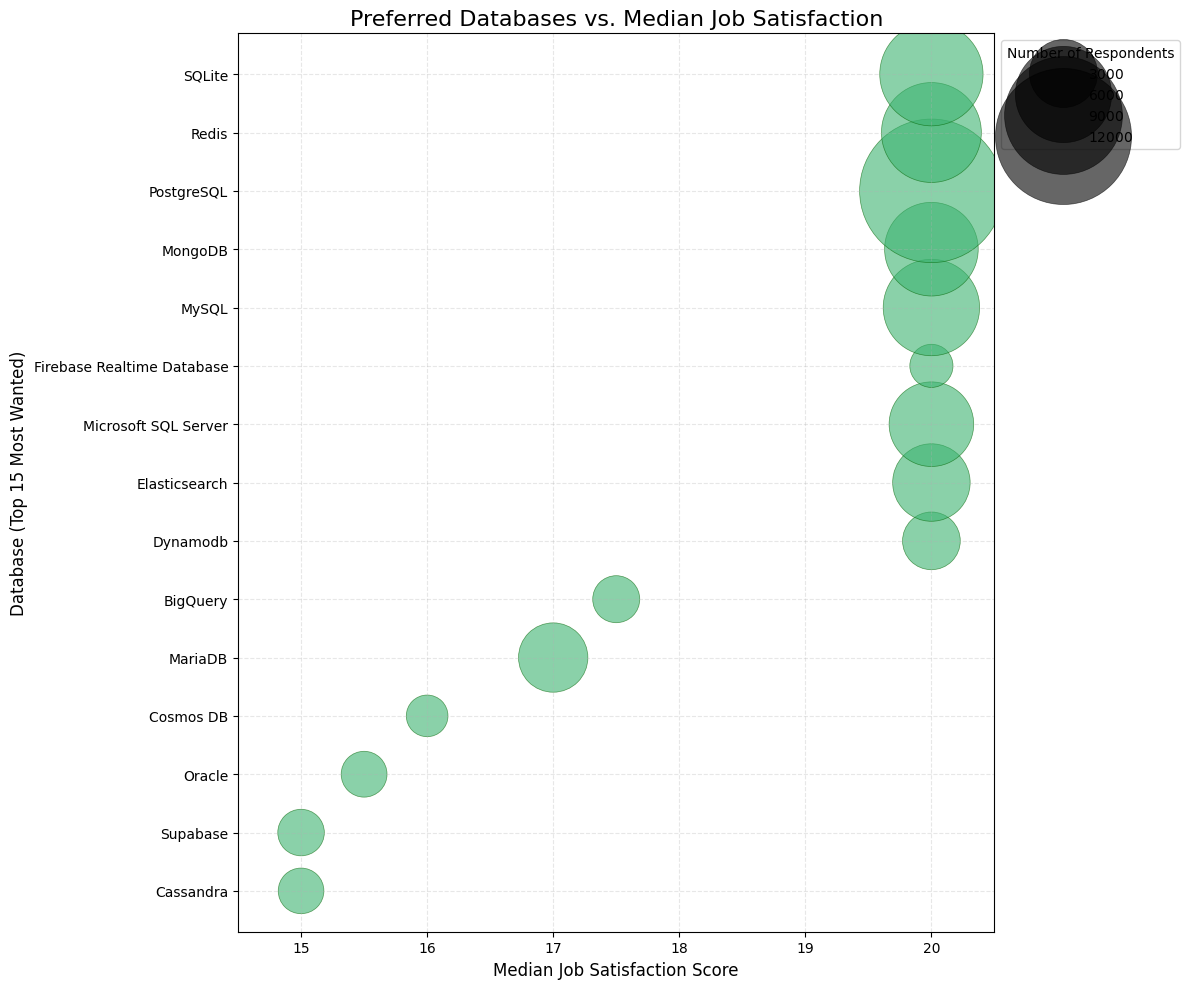

Bubble plot generated for top 15 desired databases.
X-axis: Median Job Satisfaction | Y-axis: Database Name | Bubble Size: Frequency of Preference


In [28]:
##Write your code here

# 1. Prepare Job Satisfaction Data (Numeric)
# We use JobSatPoints_6 as our satisfaction metric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# 2. Process Multi-select Databases
# Drop rows missing either the database preferences or the satisfaction score
df_clean = df.dropna(subset=['DatabaseWantToWorkWith', 'JobSatPoints_6']).copy()

# Split the semicolon-separated strings and explode into individual rows
df_clean['Database'] = df_clean['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('Database')

# 3. Aggregate Data (Median Satisfaction and Frequency per Database)
# This identifies how satisfied users of each database are and how many users there are
db_stats = df_exploded.groupby('Database')['JobSatPoints_6'].agg(['median', 'count']).reset_index()

# 4. Filter for Top 15 Most Desired Databases
# We focus on the most popular databases to keep the visualization clear
top_15_dbs = df_exploded['Database'].value_counts().nlargest(15).index
plot_data = db_stats[db_stats['Database'].isin(top_15_dbs)].sort_values(by='median')

# 5. Create the Bubble Plot
plt.figure(figsize=(12, 10))

# X-axis: Median Job Satisfaction
# Y-axis: Database Name
# Size (s): Number of respondents (frequency)
scatter = plt.scatter(
    x=plot_data['median'],
    y=plot_data['Database'],
    s=plot_data['count'] * 0.8,  # Scaling factor for bubble size
    alpha=0.6,
    color='mediumseagreen',
    edgecolors='darkgreen',
    linewidth=0.5
)

# 6. Formatting and Customization
plt.title('Preferred Databases vs. Median Job Satisfaction', fontsize=16)
plt.xlabel('Median Job Satisfaction Score', fontsize=12)
plt.ylabel('Database (Top 15 Most Wanted)', fontsize=12)

# Set X-axis limits to focus on the common satisfaction range (e.g., 5-10)
if not plot_data.empty:
    plt.xlim(plot_data['median'].min() - 0.5, plot_data['median'].max() + 0.5)

# Add a legend for bubble sizes (approximate scale)
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda s: s / 0.8)
plt.legend(handles, labels, title="Number of Respondents", loc="upper left", bbox_to_anchor=(1, 1))

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bubble plot generated for top 15 desired databases.")
print("X-axis: Median Job Satisfaction | Y-axis: Database Name | Bubble Size: Frequency of Preference")

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


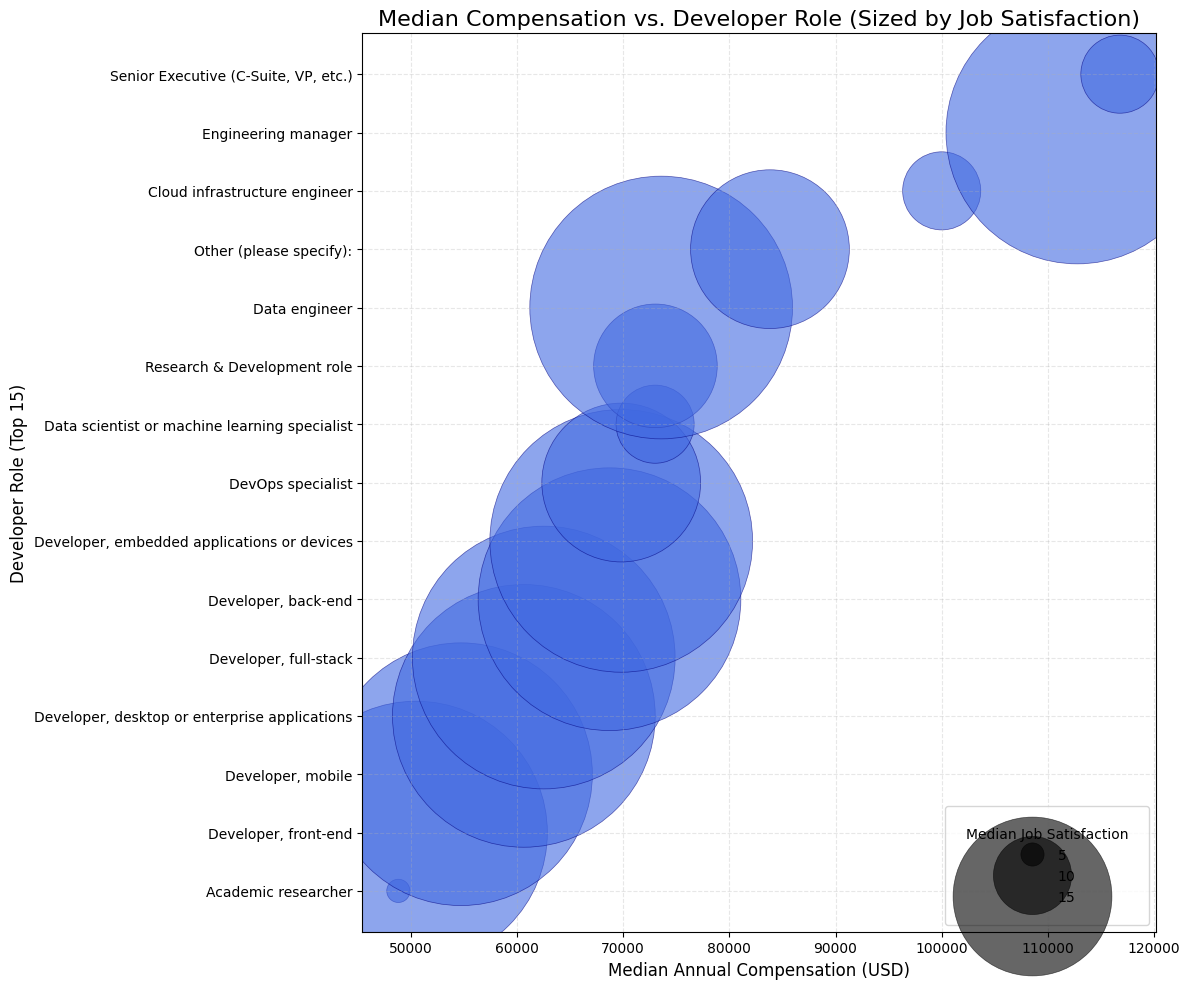

Bubble plot generated for top 15 developer roles.
X-axis: Median Compensation | Y-axis: Role | Bubble Size: Median Job Satisfaction


In [32]:
##Write your code here

# 1. Prepare Numeric Data
# Ensure compensation and job satisfaction are numeric types
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# 2. Process Multi-select Developer Roles (DevType)
# Drop rows missing either the role or the primary numeric metrics
df_clean = df.dropna(subset=['DevType', 'ConvertedCompYearly', 'JobSatPoints_6']).copy()

# Split the semicolon-separated strings (e.g., "Developer, back-end;Developer, front-end") 
# and explode into individual rows so each role is analyzed independently.
df_clean['Role'] = df_clean['DevType'].str.split(';')
df_exploded = df_clean.explode('Role')

# 3. Aggregate Data (Median Comp, Median Satisfaction, and Frequency per Role)
role_stats = df_exploded.groupby('Role').agg({
    'ConvertedCompYearly': 'median',
    'JobSatPoints_6': 'median',
    'DevType': 'count' # Use original column to count total respondents per role
}).reset_index()

role_stats.rename(columns={'DevType': 'RespondentCount'}, inplace=True)

# 4. Filter for Top 15 Most Common Developer Roles
# We focus on the most common roles to maintain visual clarity on the Y-axis
top_15_roles = df_exploded['Role'].value_counts().nlargest(15).index
plot_data = role_stats[role_stats['Role'].isin(top_15_roles)].sort_values(by='ConvertedCompYearly')

# 5. Create the Bubble Plot
plt.figure(figsize=(12, 10))

# X-axis: Median Yearly Compensation
# Y-axis: Developer Role
# Size (s): Median Job Satisfaction Score
# We scale the satisfaction score significantly to make size differences visible
scatter = plt.scatter(
    x=plot_data['ConvertedCompYearly'],
    y=plot_data['Role'],
    s=plot_data['JobSatPoints_6']**3.5,  # Exponential scaling to highlight satisfaction differences
    alpha=0.6,
    color='royalblue',
    edgecolors='navy',
    linewidth=0.5
)

# 6. Formatting and Customization
plt.title('Median Compensation vs. Developer Role (Sized by Job Satisfaction)', fontsize=16)
plt.xlabel('Median Annual Compensation (USD)', fontsize=12)
plt.ylabel('Developer Role (Top 15)', fontsize=12)

# Prevent scientific notation on the X-axis for better readability
plt.ticklabel_format(style='plain', axis='x')

# Add a legend for the bubble sizes (Satisfaction Levels)
# Since we used a power of 3.5, we map back to the original scale for the legend labels
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda s: np.power(s, 1/3.5))
plt.legend(handles, labels, title="Median Job Satisfaction", loc="lower right", borderpad=1.5)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Bubble plot generated for top 15 developer roles.")
print("X-axis: Median Compensation | Y-axis: Role | Bubble Size: Median Job Satisfaction")

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [ ]:
##Write your code here


### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [ ]:
##Write your code here

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [ ]:
##Write your code here

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
